In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pal=['#4E79A7','#F28E2B','#E15759','#76B7B2','#59A14F','#EDC948']

In [ ]:

# Load raw UCI HAR data — ne treba data/ CSV folder
def _uniq(names):
    seen, result = set(), []
    for x in names:
        candidate = x
        while candidate in seen:
            candidate += 'n'
        result.append(candidate)
        seen.add(candidate)
    return result

with open('UCI HAR Dataset/features.txt') as f:
    uniq_features = _uniq([line.split()[1] for line in f])

def load_har(split):
    base = f'UCI HAR Dataset/{split}'
    X = pd.read_csv(f'{base}/X_{split}.txt', sep=r'\s+', header=None, names=uniq_features)
    X['subject'] = pd.read_csv(f'{base}/subject_{split}.txt', header=None).squeeze()
    y = pd.read_csv(f'{base}/y_{split}.txt', header=None).squeeze()
    X['Activity']     = y.values
    X['ActivityName'] = y.map({1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                                4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}).values
    X.columns = (X.columns.str.replace(r'[()]', '', regex=True)
                           .str.replace(r'[-]',  '', regex=True)
                           .str.replace(r'[,]',  '', regex=True))
    return X

df_train = load_har('train')
df_test  = load_har('test')
print(f"Train: {df_train.shape},  Test: {df_test.shape}")


In [4]:
df_train.info()
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 564 entries, tBodyAccmeanX to ActivityName
dtypes: float64(561), int64(2), str(1)
memory usage: 31.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 564 entries, tBodyAccmeanX to ActivityName
dtypes: float64(561), int64(2), str(1)
memory usage: 12.7 MB


In [5]:
df_train.head()
df_test.head()

,tBodyAccmeanX,tBodyAccmeanY,tBodyAccmeanZ,tBodyAccstdX,tBodyAccstdY,tBodyAccstdZ,tBodyAccmadX,tBodyAccmadY,tBodyAccmadZ,tBodyAccmaxX,...,angletBodyAccMeangravity,angletBodyAccJerkMeangravityMean,angletBodyGyroMeangravityMean,angletBodyGyroJerkMeangravityMean,angleXgravityMean,angleYgravityMean,angleZgravityMean,subject,Activity,ActivityName
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,5,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,5,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,5,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,5,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,5,STANDING


In [6]:
df_train.shape
df_test.shape

(2947, 564)

In [7]:
df_train.dtypes
df_test.dtypes

tBodyAccmeanX        float64
tBodyAccmeanY        float64
tBodyAccmeanZ        float64
tBodyAccstdX         float64
tBodyAccstdY         float64
                      ...   
angleYgravityMean    float64
angleZgravityMean    float64
subject                int64
Activity               int64
ActivityName             str
Length: 564, dtype: object

In [8]:
df_train.describe()
df_test.describe()

,tBodyAccmeanX,tBodyAccmeanY,tBodyAccmeanZ,tBodyAccstdX,tBodyAccstdY,tBodyAccstdZ,tBodyAccmadX,tBodyAccmadY,tBodyAccmadZ,tBodyAccmaxX,...,fBodyBodyGyroJerkMagkurtosis,angletBodyAccMeangravity,angletBodyAccJerkMeangravityMean,angletBodyGyroMeangravityMean,angletBodyGyroJerkMeangravityMean,angleXgravityMean,angleYgravityMean,angleZgravityMean,subject,Activity
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720,12.986427,3.577876
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467,6.950984,1.740348
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228,2.000000,1.000000
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485,9.000000,2.000000
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671,12.000000,4.000000
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373,18.000000,5.000000
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113,24.000000,6.000000


In [9]:
df_train.isna().sum().sum()
df_test.isna().sum().sum()

np.int64(0)

 > Odavde vidimo da ne postoji `NaN` vrednosti, odnosno da nema nedostajucih vrednosti prediktora. 



In [10]:
df_train.duplicated().sum()
df_test.duplicated().sum()

np.int64(0)

> Ovde vidimo da ne postoje duplikati

In [11]:
df_train.columns
df_test.columns

Index(['tBodyAccmeanX', 'tBodyAccmeanY', 'tBodyAccmeanZ', 'tBodyAccstdX',
       'tBodyAccstdY', 'tBodyAccstdZ', 'tBodyAccmadX', 'tBodyAccmadY',
       'tBodyAccmadZ', 'tBodyAccmaxX',
       ...
       'angletBodyAccMeangravity', 'angletBodyAccJerkMeangravityMean',
       'angletBodyGyroMeangravityMean', 'angletBodyGyroJerkMeangravityMean',
       'angleXgravityMean', 'angleYgravityMean', 'angleZgravityMean',
       'subject', 'Activity', 'ActivityName'],
      dtype='str', length=564)

> S obzirom na ovoliki broj prediktora, ne mozemo verodostojno analizirati `data`

In [12]:
target_column = df_train.columns[-1]

print("Target column:", target_column)
df_train[target_column].value_counts()

Target column: ActivityName


ActivityName
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

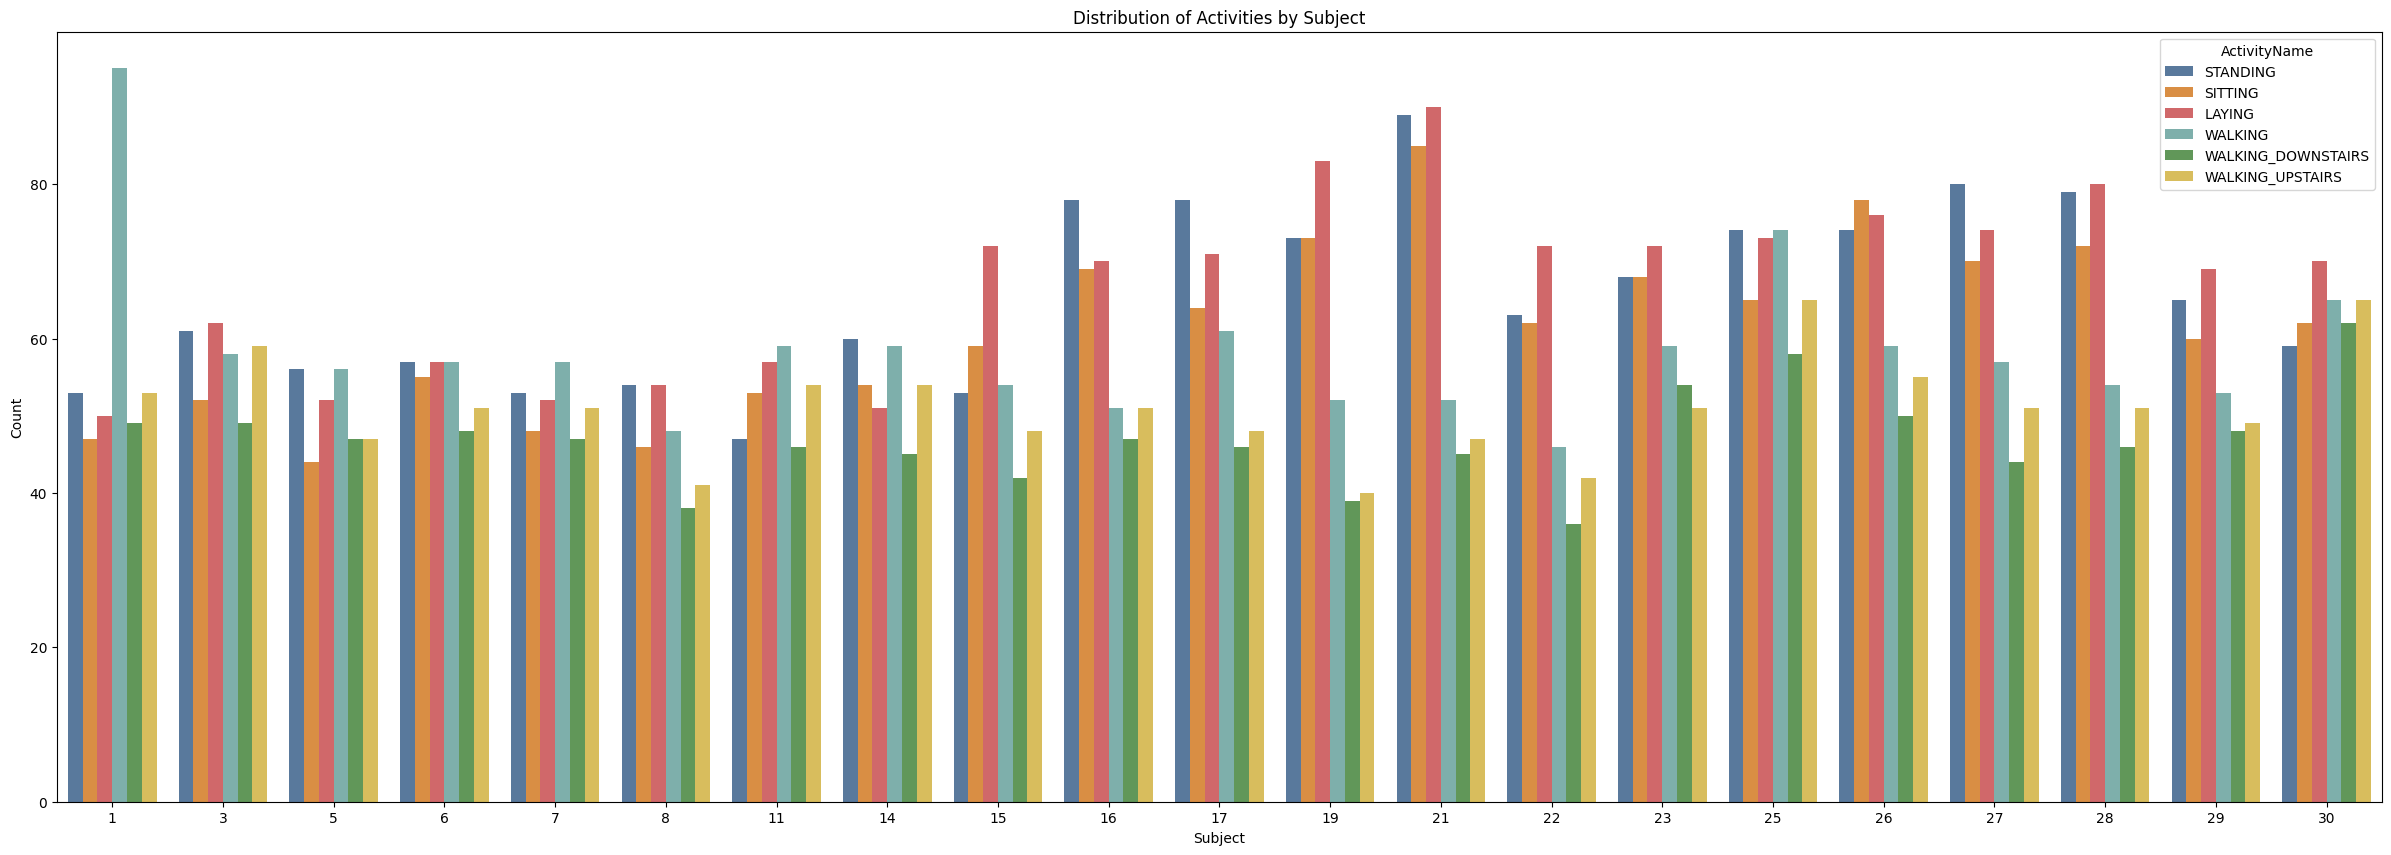

In [14]:
plt.figure(figsize=(30, 10))
sns.countplot(x='subject',hue='ActivityName',palette=pal,data=df_train)
plt.title("Distribution of Activities by Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()


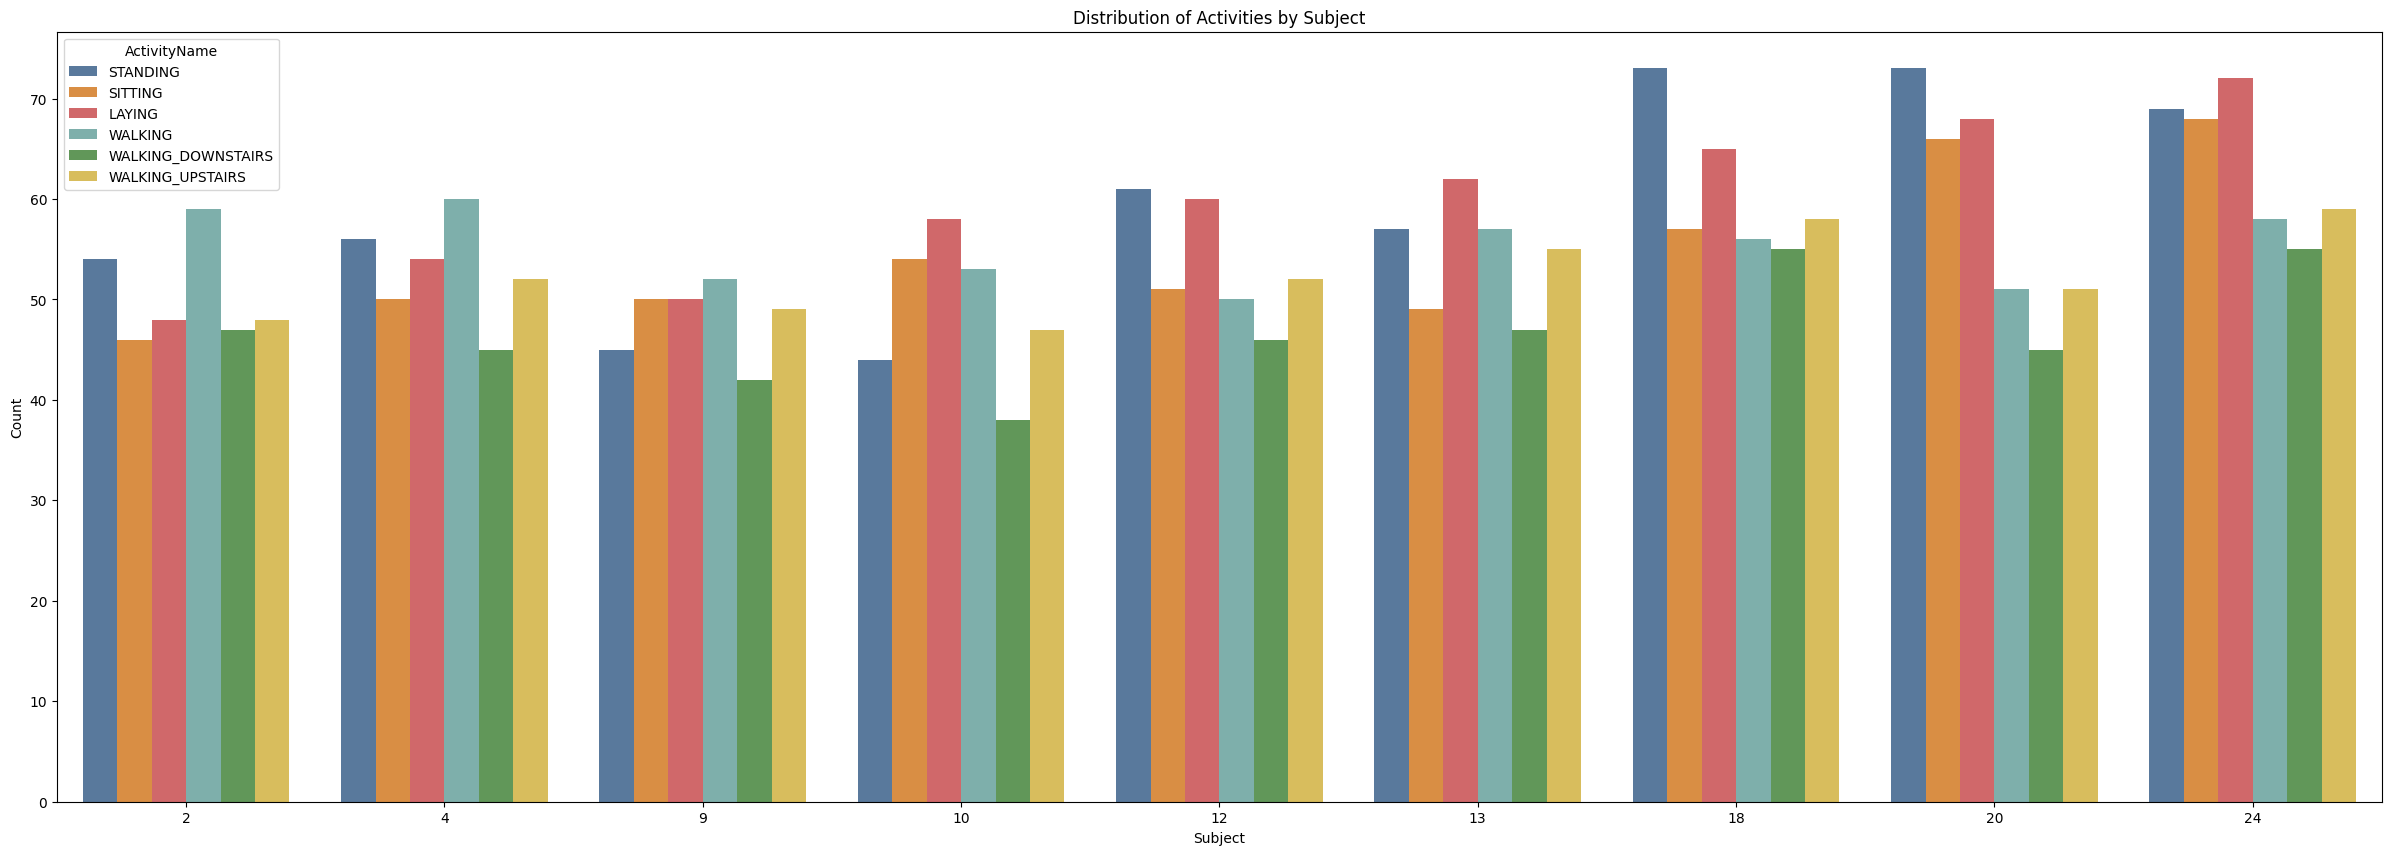

In [15]:
plt.figure(figsize=(30, 10))
sns.countplot(x='subject',hue='ActivityName',palette=pal,data=df_test)
plt.title("Distribution of Activities by Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()


C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1316832454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_column, palette=pal, data=df_train)


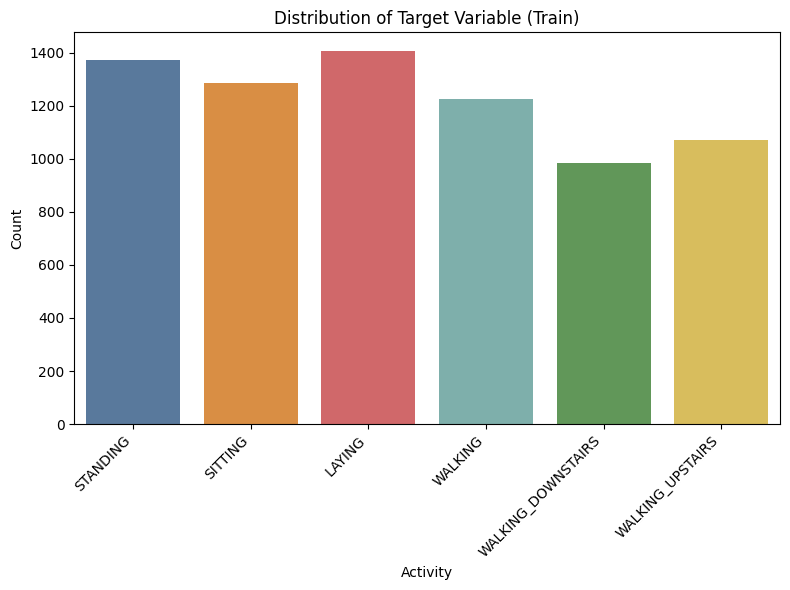

In [16]:

# Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
plt.title("Distribution of Target Variable (Train)")
sns.countplot(x=target_column, palette=pal, data=df_train)
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1216483563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_column, palette=pal, data=df_test)


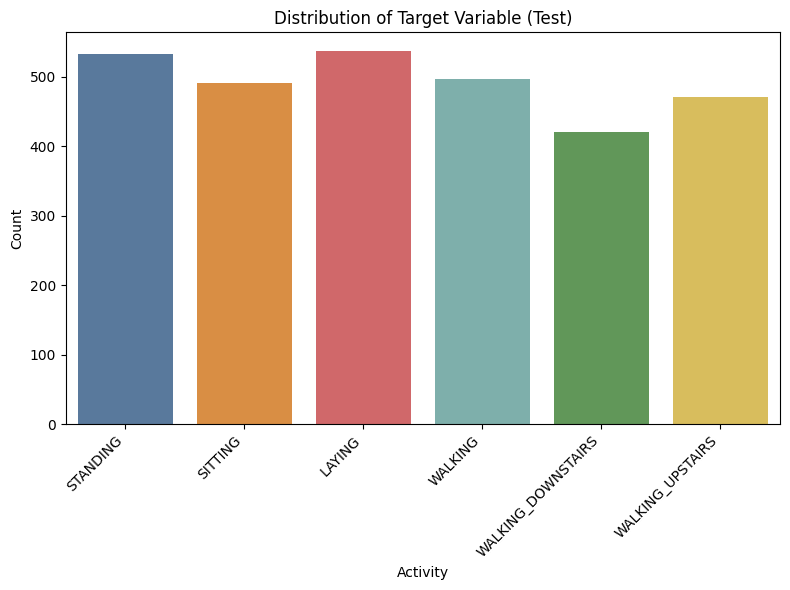

In [17]:

# Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
plt.title("Distribution of Target Variable (Test)")
sns.countplot(x=target_column, palette=pal, data=df_test)
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("target_distribution_test.png", dpi=120, bbox_inches="tight")
plt.show()


C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1507639790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ActivityName", y=col, data=df_train,
C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1507639790.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1507639790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ActivityName", y=col, data=df_train,
C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1507639790.py:15: UserWarning: set_ticklabels() should only be u

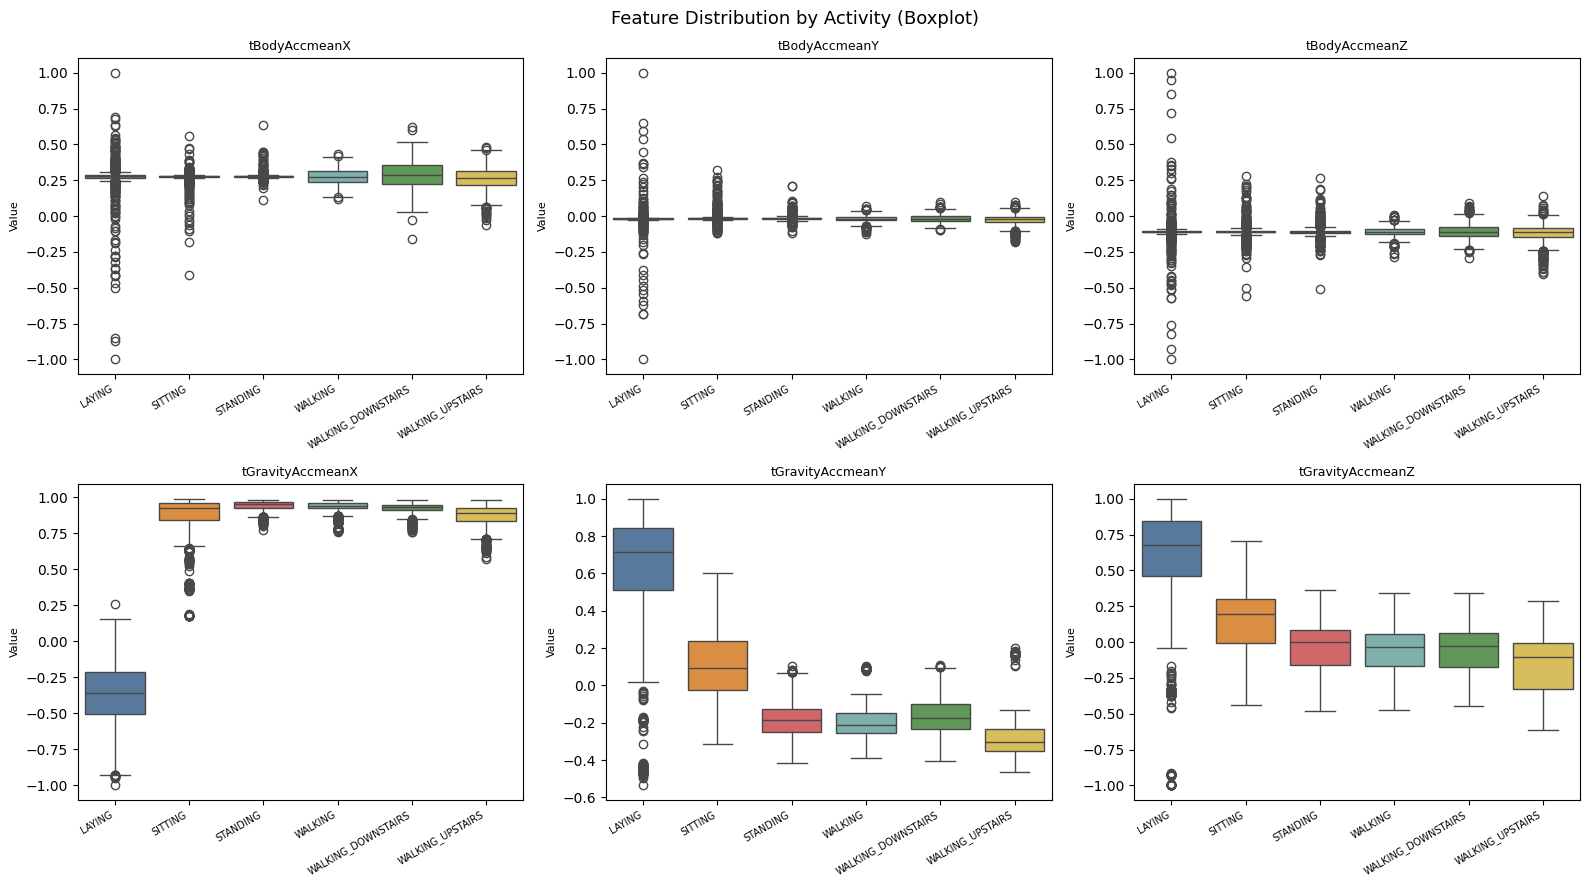

In [18]:

# Boxplot distribucije po klasi za 6 mean prediktora
mean_cols = [c for c in df_train.columns if "mean" in c.lower()
             and c not in ("subject", "Activity", "ActivityName")][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distribution by Activity (Boxplot)", fontsize=13)

for plot_i, col in enumerate(mean_cols):
    ax = axes[plot_i // 3][plot_i % 3]
    sns.boxplot(x="ActivityName", y=col, data=df_train,
                palette=pal, ax=ax, order=sorted(df_train["ActivityName"].unique()))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Value", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)

plt.tight_layout()
plt.savefig("boxplot_mean_features.png", dpi=120, bbox_inches="tight")
plt.show()



> Boxplot jasno pokazuje razliku između statičnih aktivnosti (LAYING, SITTING, STANDING) i dinamičnih (WALKING*). Ovo je važan signal — dataset je separabilan.


C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\3567093300.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  numeric_df["Activity"] = df_train["Activity"]


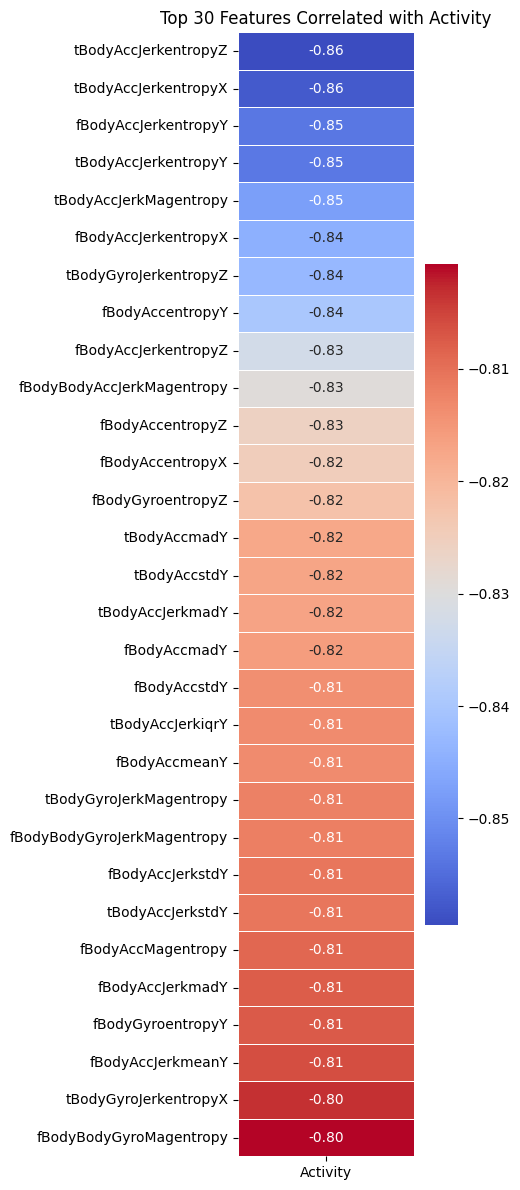

In [19]:

# Top 30 featuri po korelaciji sa ciljnom promenljivom
numeric_df = df_train.select_dtypes(include=[np.number]).drop(columns=["subject", "Activity"])
numeric_df["Activity"] = df_train["Activity"]

corr_with_target = numeric_df.corr()["Activity"].drop("Activity")
target_corr = (corr_with_target
               .reindex(corr_with_target.abs().sort_values(ascending=False).index)
               .head(30)
               .to_frame(name="Activity"))

plt.figure(figsize=(5, 12))
sns.heatmap(target_corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Top 30 Features Correlated with Activity")
plt.tight_layout()
plt.savefig("corr_with_target.png", dpi=120, bbox_inches="tight")
plt.show()



> Featuri sa visokom apsolutnom korelacijom sa targetom su dobri kandidati za predikciju. Crvena = pozitivna korelacija, plava = negativna.


In [20]:

# Inter-feature korelacija — provera redundantnosti (gornji trougao, prag 0.95)
feat_cols = [c for c in df_train.columns if c not in ("subject", "Activity", "ActivityName")]
corr_matrix = df_train[feat_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Ukupno featuri       : {len(feat_cols)}")
print(f"Visoko korelirani (>0.95): {len(to_drop)}")
print(f"Preostaje            : {len(feat_cols) - len(to_drop)}")


Ukupno featuri       : 561
Visoko korelirani (>0.95): 308
Preostaje            : 253



> Veliki broj featuri je visoko koreliran međusobno — to znači redundantnost. Pre treniranja modela treba razmotriti uklanjanje jednog od para (visoko koreliranih) featuri ili primeniti PCA.


C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1906465919.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")
C:\Users\nikol\AppData\Local\Temp\ipykernel_70168\1906465919.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


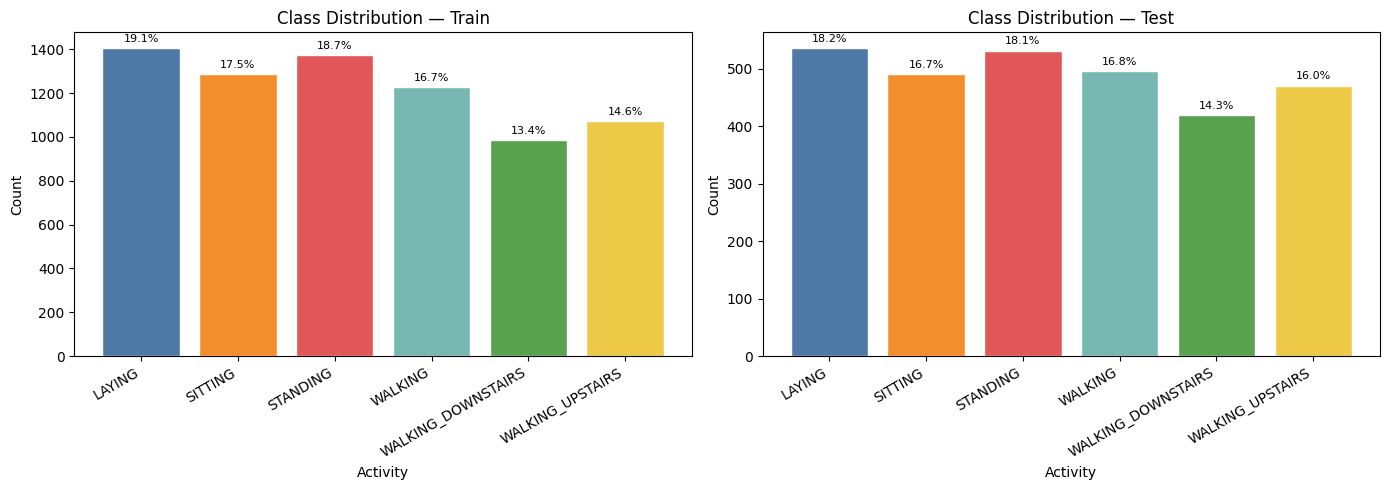

In [22]:

# Train vs Test — distribucija po klasi (provera distribution shift)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [df_train, df_test], ["Train", "Test"]):
    counts = df["ActivityName"].value_counts().reindex(sorted(df["ActivityName"].unique()))
    total  = counts.sum()
    pct    = (counts / total * 100).round(1)
    bars   = ax.bar(counts.index, counts.values,
                    color=pal[:len(counts)], edgecolor="white")
    ax.bar_label(bars, labels=[f"{p}%" for p in pct], padding=3, fontsize=8)
    ax.set_title(f"Class Distribution — {title}")
    ax.set_xlabel("Activity")
    ax.set_ylabel("Count")
    ax.set_xticklabels(counts.index, rotation=30, ha="right")

plt.tight_layout()
plt.savefig("train_test_distribution.png", dpi=120, bbox_inches="tight")
plt.show()



> Ako su procenti po klasama slični u train i test skupu — nema distribution shift-a i model će se generalizovati. Ako postoji razlika — treba koristiti stratifikovano uzorkovanje pri CV.


In [23]:
df_train["ActivityName"].unique()

<StringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str

In [24]:
df_train.columns[190:210]

Index(['tBodyGyroJerkarCoeffY2', 'tBodyGyroJerkarCoeffY3',
       'tBodyGyroJerkarCoeffY4', 'tBodyGyroJerkarCoeffZ1',
       'tBodyGyroJerkarCoeffZ2', 'tBodyGyroJerkarCoeffZ3',
       'tBodyGyroJerkarCoeffZ4', 'tBodyGyroJerkcorrelationXY',
       'tBodyGyroJerkcorrelationXZ', 'tBodyGyroJerkcorrelationYZ',
       'tBodyAccMagmean', 'tBodyAccMagstd', 'tBodyAccMagmad', 'tBodyAccMagmax',
       'tBodyAccMagmin', 'tBodyAccMagsma', 'tBodyAccMagenergy',
       'tBodyAccMagiqr', 'tBodyAccMagentropy', 'tBodyAccMagarCoeff1'],
      dtype='str')

In [ ]:

# Differentiate between laying and sitting/standing
feature_cols = ["tGravityAcc-mean()-Z", "tGravityAcc-mean()-X"]
Activities = ["LAYING", "SITTING", "STANDING"]
plot_feature_cols = [col.replace("-mean()-", "mean").replace("-", "") for col in feature_cols]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=plot_feature_cols[0], y=plot_feature_cols[1],
                hue="ActivityName", palette=pal,
                data=df_train[df_train["ActivityName"].isin(Activities)],
                alpha=0.5, s=20)
plt.title("Scatter Plot — tGravityAcc Z vs X (static activities)")
plt.xlabel(plot_feature_cols[0])
plt.ylabel(plot_feature_cols[1])
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("scatter_static_activities.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

# Separation: walking vs not walking using fBodyAccMag-energy
feature_col = "fBodyAccMagenergy"

plt.figure(figsize=(10, 5))
sns.boxplot(x="ActivityName", y=feature_col, data=df_train, palette=pal)
plt.title("Box Plot of fBodyAccMag-energy by Activity")
plt.xlabel("Activity")
plt.ylabel("fBodyAccMag-energy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("boxplot_energy_by_activity.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

# Violin plot — SITTING vs STANDING separation
sit_stand    = df_train[df_train["ActivityName"].isin(["SITTING", "STANDING"])]
best_features = ["tGravityAcccorrelationXY", "tGravityAccmeanY"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(best_features):
    sns.violinplot(x="ActivityName", y=feat, hue="ActivityName",
                   data=sit_stand, palette=[pal[3], pal[4]],
                   ax=axes[i], inner="box", legend=False)
    axes[i].set_title(f"SITTING vs STANDING\n{feat}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat)

plt.suptitle("SITTING vs STANDING — najinformativniji featuri",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("violin_sitting_standing.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

# Reprezentativni featuri iz svake grupe signala — mean +/- std po aktivnosti
representative_features = [
    "tBodyAccmeanX",    # akcelerometar - telo
    "tBodyAccstdX",
    "tGravityAccmeanX", # gravitacija
    "tBodyAccJerkmeanX",# jerk
    "tBodyGyromeanX",   # ziroskop
    "tBodyAccMagmean",  # magnituда
    "tBodyAccMagstd",
    "fBodyAccmeanX",    # frekventni domen
    "fBodyGyromeanX",
]

group_means = df_train.groupby("ActivityName")[representative_features].mean()
group_stds  = df_train.groupby("ActivityName")[representative_features].std()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(representative_features):
    axes[i].bar(range(6), group_means[feat], yerr=group_stds[feat],
                capsize=4, color=pal, edgecolor="white")
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xticks(range(6))
    axes[i].set_xticklabels([a.replace("_", "\n") for a in group_means.index],
                             fontsize=6, rotation=15)
    sns.despine(ax=axes[i])

fig.suptitle("Srednje vrednosti +/- std po aktivnosti (reprezentativni featuri)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("barplot_representative_features.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

# Korelaciona matrica — reprezentativni featuri
corr_matrix = df_train[representative_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korelaciona matrica reprezentativnih featuri",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("corr_matrix_representative.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df_train.columns if c not in ["Activity", "ActivityName", "subject"]]
X            = df_train[feature_cols].values
y_labels     = df_train["ActivityName"].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {explained[0]:.1f}%  |  PC2: {explained[1]:.1f}%  |  Ukupno: {explained.sum():.1f}%")

plt.figure(figsize=(9, 7))
for activity, color in zip(sorted(df_train["ActivityName"].unique()), pal):
    mask = y_labels == activity
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=activity, alpha=0.4, s=15, linewidths=0)

plt.xlabel(f"PC1 ({explained[0]:.1f}% varijanse)", fontsize=11)
plt.ylabel(f"PC2 ({explained[1]:.1f}% varijanse)", fontsize=11)
plt.title("PCA projekcija UCI HAR dataseta (train skup)", fontsize=13, fontweight="bold")
plt.legend(markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("pca_2d.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:

from sklearn.manifold import TSNE

# Pre-redukcija na 50 komponenti radi brzine t-SNE
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

print("Pokrecem t-SNE, sacekaj (1-2 min)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("Gotovo!")

plt.figure(figsize=(9, 7))
for activity, color in zip(sorted(df_train["ActivityName"].unique()), pal):
    mask = y_labels == activity
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=activity, alpha=0.4, s=15, linewidths=0)

plt.xlabel("t-SNE dim 1", fontsize=11)
plt.ylabel("t-SNE dim 2", fontsize=11)
plt.title("t-SNE projekcija UCI HAR dataseta (train skup)", fontsize=13, fontweight="bold")
plt.legend(markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("tsne_2d.png", dpi=120, bbox_inches="tight")
plt.show()
